In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/heart-disease-dataset/heart.csv


# Uploading the dataset:

In [2]:
df=pd.read_csv('/kaggle/input/heart-disease-dataset/heart.csv')

In [3]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


# Exploring the dataset:

In [4]:
df.shape

(1025, 14)

In [5]:
df['target'].value_counts()

target
1    526
0    499
Name: count, dtype: int64

In [6]:
df.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

In [7]:
import matplotlib.pyplot as plt

<Axes: >

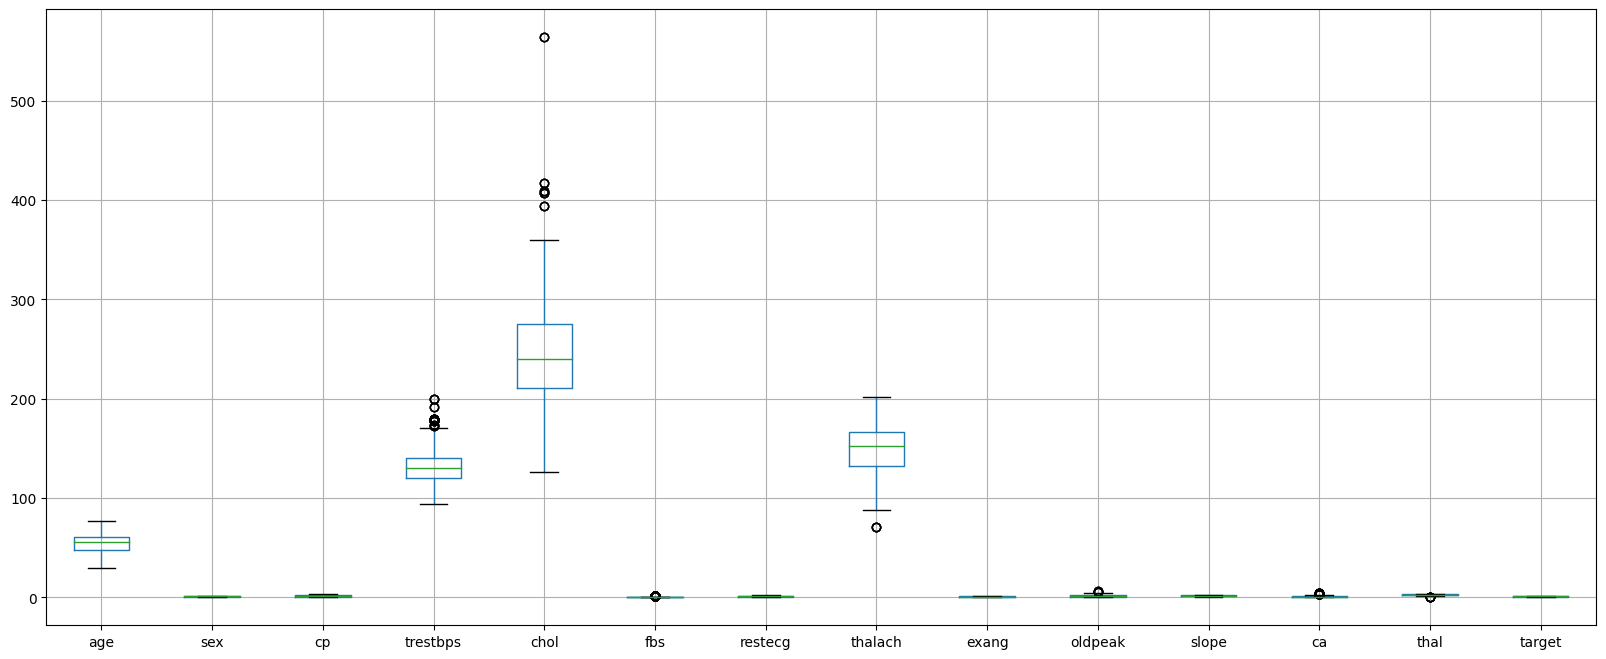

In [8]:
df.boxplot(figsize=(20,8))

# Handling the outlier:

In [9]:
# Function to detect and clip outliers using IQR
def clip_outliers_iqr(column):
    Q1 = column.quantile(0.25)
    Q3 = column.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    # Clipping the column values to the lower and upper bounds
    return column.clip(lower=lower_bound, upper=upper_bound)

# Apply the clipping function to numerical columns
for col in df.select_dtypes(include=['float64', 'int64']).columns:
    df[col] = clip_outliers_iqr(df[col])

# Display the DataFrame after clipping
df.head()


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2.0,3.0,0
1,53,1,0,140,203,0,0,155,1,3.1,0,0.0,3.0,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0.0,3.0,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1.0,3.0,0
4,62,0,0,138,294,0,1,106,0,1.9,1,2.5,2.0,0


<Axes: >

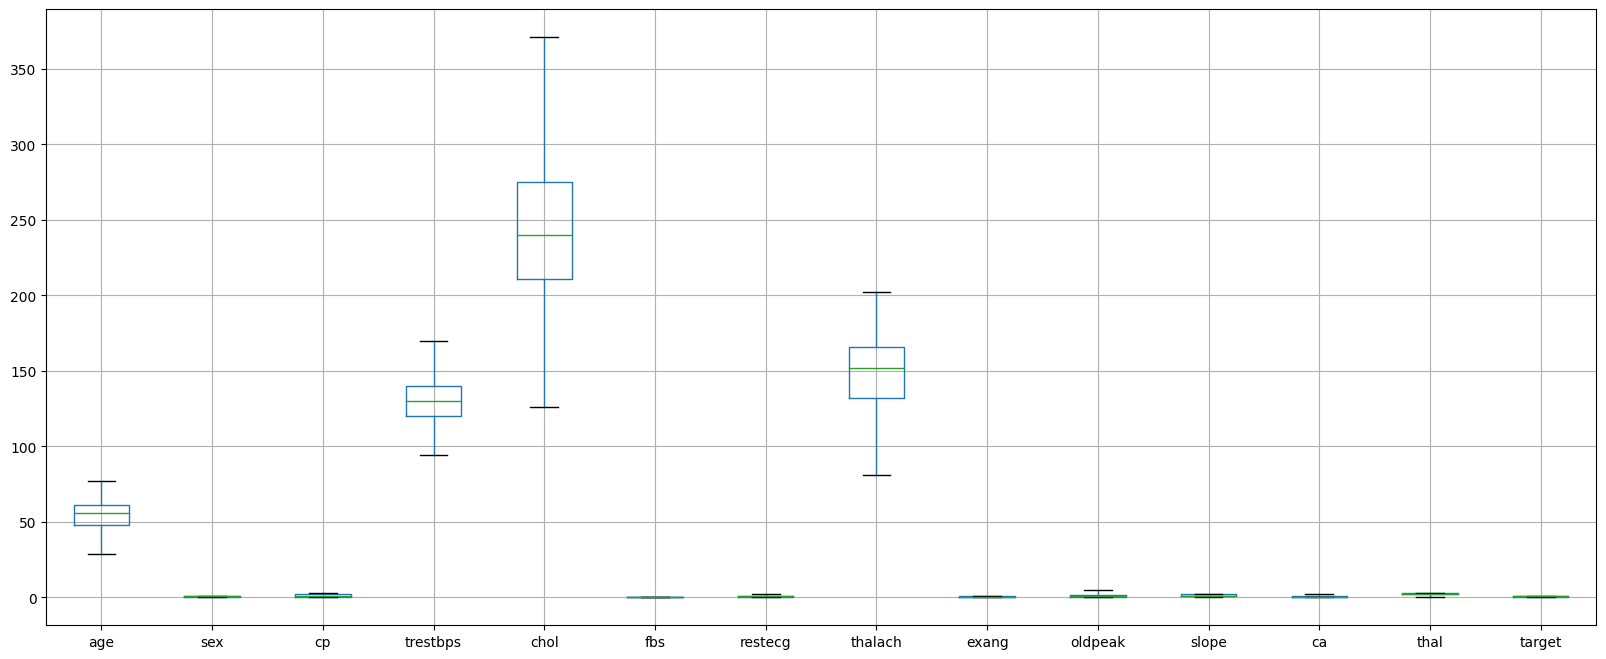

In [10]:
df.boxplot(figsize=(20,8))

# Splitting the dataset in training and testing:

In [11]:
x=df.drop('target',axis=1)
y=df['target']

In [12]:
from sklearn.model_selection import train_test_split

In [13]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=41)

In [14]:
x_train.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
365,53,1,2,130,246,0,0,173,0,0.0,2,2.5,2.0
887,57,1,0,110,201,0,1,126,1,1.5,1,0.0,1.0
955,62,1,2,130,231,0,1,146,0,1.8,1,2.5,3.0
329,53,0,2,128,216,0,0,115,0,0.0,2,0.0,0.5
861,64,1,2,140,335,0,1,158,0,0.0,2,0.0,2.0


# Training the model using DecisionTree:

In [15]:
from sklearn.tree import DecisionTreeClassifier,plot_tree

In [16]:
model_dt=DecisionTreeClassifier()

In [17]:
model_dt.fit(x_train,y_train)

DecisionTreeClassifier()

In [18]:
y_pred_dt=model_dt.predict(x_test)

In [19]:
y_pred_dt

array([1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 0,
       1, 0, 1, 0, 1, 1, 1, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0,
       0, 0, 1, 0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 1, 0,
       0, 1, 0, 1, 1, 1, 0, 1, 0, 0, 0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 1,
       0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0, 1, 1, 1, 0, 1,
       1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 0, 1, 1, 0, 1,
       1, 0, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1, 1, 0, 0, 0, 1, 0, 1, 1, 1, 0,
       0, 0, 0, 1, 1, 0, 1, 1, 1, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0, 1,
       1, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0,
       1, 1, 1, 1, 1, 0, 1])

In [20]:
from sklearn.metrics import accuracy_score

In [21]:
accuracy_score(y_test,y_pred_dt)

1.0

# Visualize the decision tree:

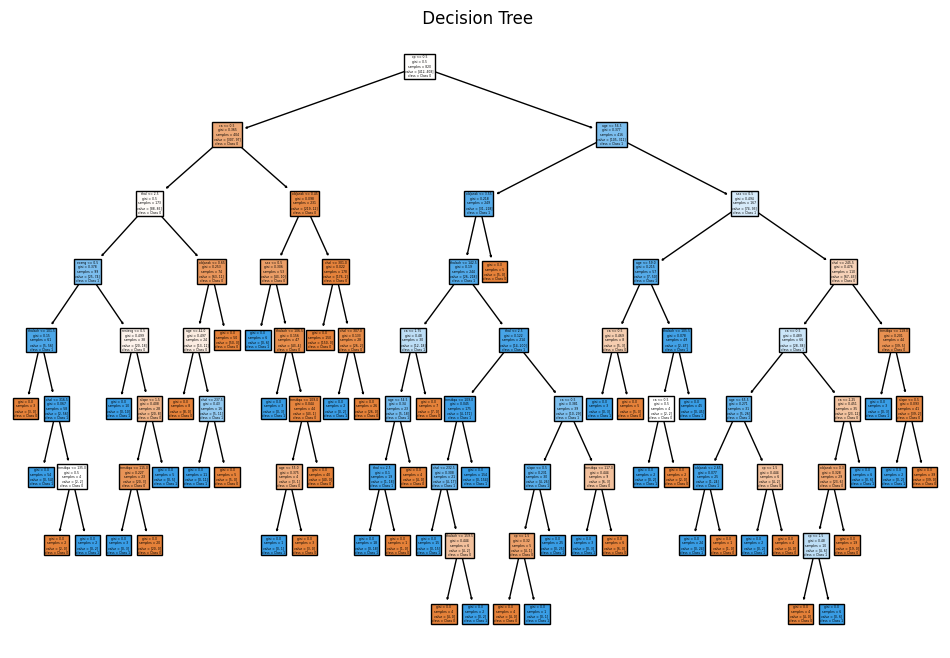

In [22]:
plt.figure(figsize=(12, 8))
plot_tree(model_dt,
          feature_names=['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
                         'exang', 'oldpeak', 'slope', 'ca', 'thal'],  # Exclude 'target' column
          class_names=["Class 0", "Class 1"],  # Replace with your actual class names
          filled=True)
plt.title(" Decision Tree")
plt.show()

# Perfoming the cross validation for analysing the overfitting:

In [23]:
from sklearn.model_selection import cross_val_score

In [24]:
score=cross_val_score(model_dt,x_train,y_train,cv=10)

In [25]:
score

array([1.        , 1.        , 0.98780488, 0.97560976, 1.        ,
       1.        , 1.        , 0.98780488, 1.        , 0.98780488])

In [26]:
score.mean()

0.9939024390243902

# Training the model using RandomForest:

In [27]:
from sklearn.ensemble import RandomForestClassifier

In [28]:
rf_model=RandomForestClassifier()

In [29]:
rf_model.fit(x_train,y_train)

RandomForestClassifier()

In [30]:
y_pred_rf=rf_model.predict(x_test)

In [31]:
y_pred_rf

array([1, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 1, 1, 0, 1, 0, 0,
       1, 0, 1, 0, 1, 1, 1, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 1, 1, 0,
       0, 0, 1, 0, 0, 1, 1, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 1, 0,
       0, 1, 0, 1, 1, 1, 0, 1, 0, 0, 0, 1, 1, 1, 1, 1, 0, 1, 0, 0, 0, 1,
       0, 0, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0, 1, 1, 1, 0, 1,
       1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 0, 1, 0, 0, 1, 1, 0, 1,
       1, 0, 1, 0, 0, 1, 1, 0, 0, 1, 1, 1, 1, 0, 0, 0, 1, 0, 1, 1, 1, 0,
       0, 0, 0, 1, 1, 0, 1, 1, 1, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0, 1,
       1, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0,
       1, 1, 1, 1, 1, 0, 1])

In [32]:
accuracy_score(y_test,y_pred_rf)

1.0

In [33]:
score_rf=cross_val_score(rf_model,x_train,y_train,cv=10)
score_rf.mean()

0.9939024390243902